
Средняя доля выбросов (1000 экспериментов)
------------------------------------------

Нормальное распределение
n = 20: доля выбросов ≈ 0.0221
n = 100: доля выбросов ≈ 0.0102


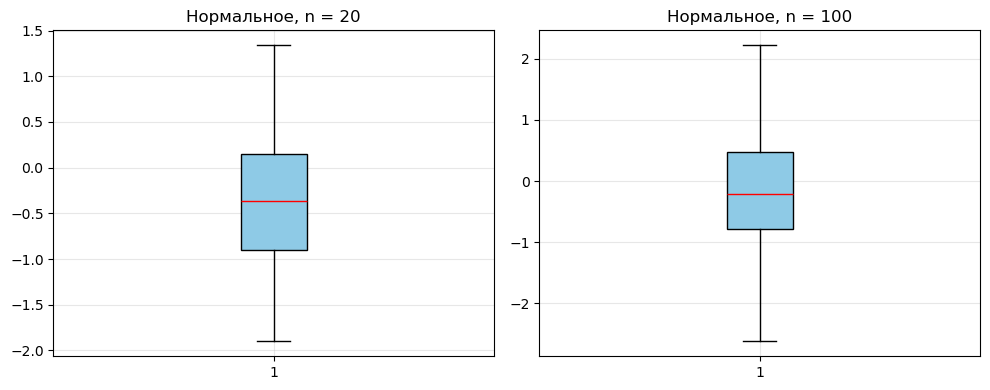


Коши распределение
n = 20: доля выбросов ≈ 0.1523
n = 100: доля выбросов ≈ 0.1545


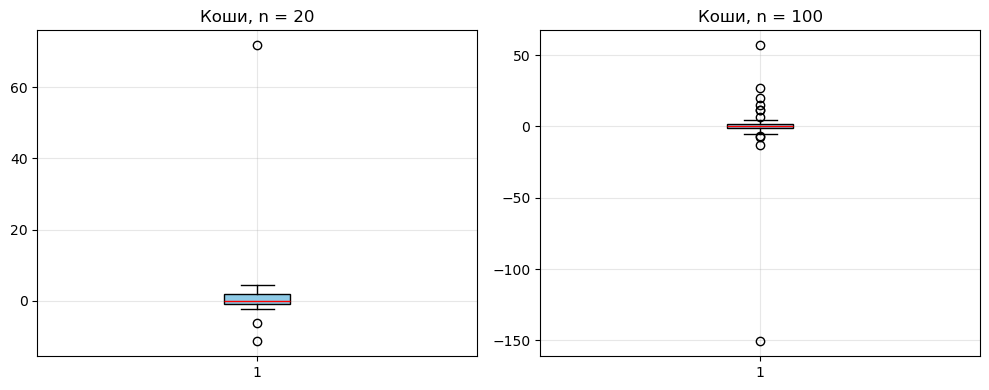


Лапласа распределение
n = 20: доля выбросов ≈ 0.0714
n = 100: доля выбросов ≈ 0.0656


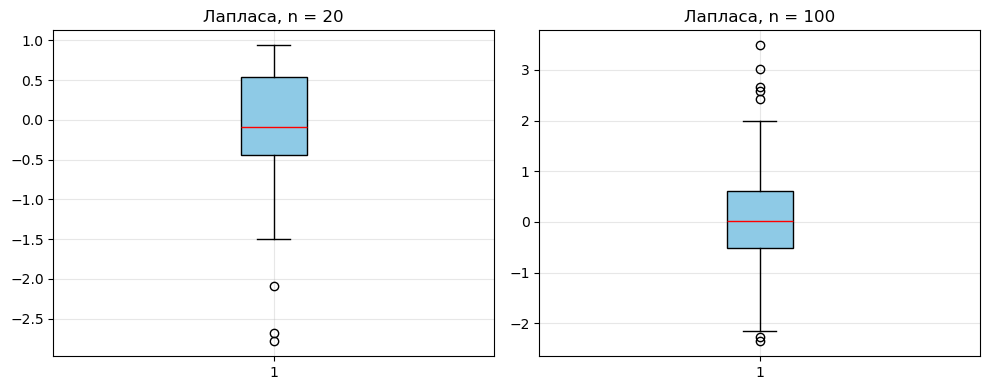


Пуассона распределение
n = 20: доля выбросов ≈ 0.0251
n = 100: доля выбросов ≈ 0.0114


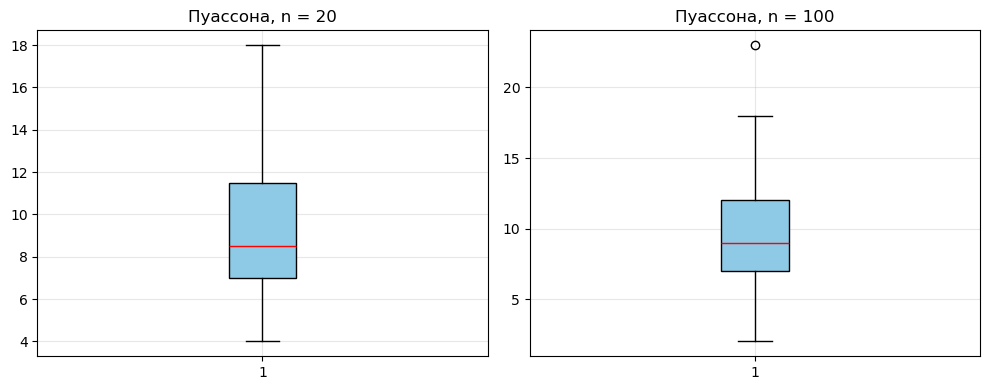


Равномерное распределение
n = 20: доля выбросов ≈ 0.0027
n = 100: доля выбросов ≈ 0.0000


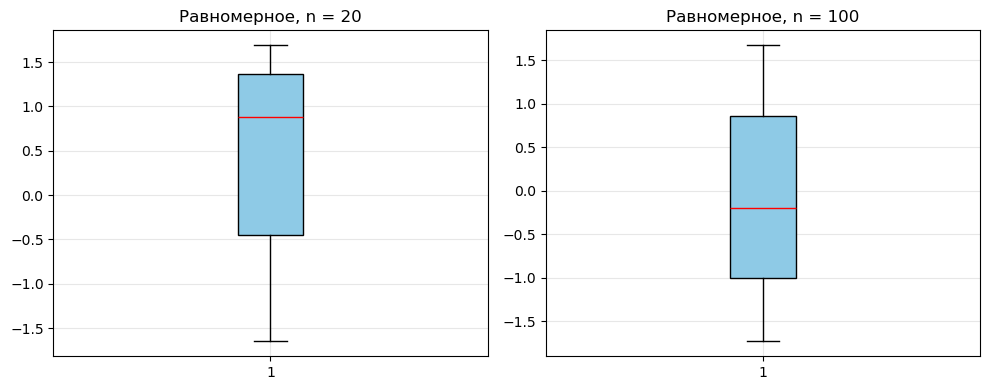

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats



def tukey_limits(sample):
    q1 = np.percentile(sample, 25)
    q3 = np.percentile(sample, 75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return lower, upper


# поиск выбросов в выборке
def detect_outliers(sample):
    lower, upper = tukey_limits(sample)
    mask = (sample < lower) | (sample > upper)
    return sample[mask]


# доля выбросов в одной выборке
def outlier_fraction(sample):
    outliers = detect_outliers(sample)
    return len(outliers) / len(sample)


# средняя доля выбросов по 1000 экспериментам
def average_outlier_share(generator, n, repeats=1000):

    shares = []

    for _ in range(repeats):
        sample = generator(n)
        share = outlier_fraction(sample)
        shares.append(share)

    return np.mean(shares)


def draw_boxplots(samples, dist_name, sizes):

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    for ax, sample, n in zip(axes, samples, sizes):

        ax.boxplot(
            sample,
            vert=True,
            patch_artist=True,
            boxprops=dict(facecolor="#8ecae6"),
            medianprops=dict(color="red"),
        )

        ax.set_title(f"{dist_name}, n = {n}")
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def run_lab():

    rng = np.random.default_rng(7)

    sizes = [20, 100]

    generators = {
        "Нормальное": lambda n: rng.normal(0, 1, n),
        "Коши": lambda n: rng.standard_cauchy(n),
        "Лапласа": lambda n: rng.laplace(0, 1 / np.sqrt(2), n),
        "Пуассона": lambda n: rng.poisson(10, n),
        "Равномерное": lambda n: rng.uniform(-np.sqrt(3), np.sqrt(3), n)
    }

    print("\nСредняя доля выбросов (1000 экспериментов)")

    for name, gen in generators.items():

        print(f"\n{name} распределение")

        samples_for_plot = []

        for n in sizes:

            # одна выборка для графика
            sample = gen(n)
            samples_for_plot.append(sample)
            share = average_outlier_share(gen, n)

            print(f"n = {n}: доля выбросов ≈ {share:.4f}")

        draw_boxplots(samples_for_plot, name, sizes)


if __name__ == "__main__":
    run_lab()